In [1]:
import warnings
warnings.filterwarnings("ignore")  # Ignore all warnings

import numpy as np
import matplotlib.pyplot as plt
from agentic_energy.milp.milp_mcp_server import records_to_arrays, solve_daily_milp
from agentic_energy.data_loader import EnergyDataLoader, BatteryDataLoader
from agentic_energy.schemas import BatteryParams, DayInputs, EnergyDataRecord, SolveFromRecordsRequest

Available LLM providers: ['gemini', 'openai', 'ollama']


In [2]:
data_version = "forecast"
forecast_type = "RF"
duration_hours=4
soc_init=0.5
soc_min=0.0
soc_max=1.0
eta_c = 0.95
eta_d = 0.95
soc_target=0.5
start_date="2019-12-01"
end_date="2019-12-08"

In [3]:
italy_forecast_obj = EnergyDataLoader(region = "ITALY", data_version=data_version, forecast_type=forecast_type)
italy_forecast_data = italy_forecast_obj.load_region_data()
italy_forecast = await italy_forecast_obj.get_filtered_data(start_date, end_date)

2025-12-09 17:30:40.950 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_forecast_RF.csv


In [4]:
italy_obj = EnergyDataLoader(region="ITALY", data_version = "actual")
italy_data = italy_obj.load_region_data()
italy_data = await italy_obj.get_filtered_data(start_date=start_date, end_date=end_date)

2025-12-09 17:30:42.123 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_actual.csv


In [5]:
stats= await EnergyDataLoader.get_summary_stats_from_ag(italy_data)
print(stats.pretty_print())

aType : <class 'agentic_energy.schemas.SummaryStats'>
region: ITALY
total_records: 192
date_range:
  start: '2019-12-01 00:00:00'
  end: '2019-12-08 23:00:00'
prices:
  count: 192
  min: 32.17
  max: 83.5
  avg: 55.91432291666666
  median: 56.32
  p25: 48.8125
  p75: 61.225
  std: 10.454785465273378
  var: 109.3025391248915
consumption:
  count: 192
  min: 20.74
  max: 45.5
  avg: 33.7065625
  median: 34.43000000000001
  p25: 27.3875
  p75: 39.95
  std: 6.806750605729121
  var: 46.331853808593756


aType : <class 'agentic_energy.schemas.SummaryStats'>
region: ITALY
total_records: 192
date_range:
  start: '2019-12-01 00:00:00'
  end: '2019-12-08 23:00:00'
prices:
  count: 192
  min: 32.17
  max: 83.5
  avg: 55.91432291666666
  median: 56.32
  p25: 48.8125
  p75: 61.225
  std: 10.454785465273378
  var: 109.3025391248915
consumption:
  count: 192
  min: 20.74
  max: 45.5
  avg: 33.7065625
  median: 34.43000000000001
  p25: 27.3875
  p75: 39.95
  std: 6.806750605729121
  var: 46.3318538085

In [6]:
from datetime import datetime, timedelta
timedelta = datetime.strptime(stats.states[0].date_range.end, "%Y-%m-%d %H:%M:%S") - datetime.strptime(stats.states[0].date_range.start, "%Y-%m-%d %H:%M:%S")
days = timedelta.days + 1
days

8

In [7]:
batt = BatteryDataLoader(
    load_stats={
        "p25":stats.states[0].consumption.p25,
        "p75":stats.states[0].consumption.p75
    },
    duration_hours=duration_hours,
    soc_init=soc_init,
    soc_min=soc_min,
    soc_max=soc_max,
    eta_c = eta_c,
    eta_d = eta_d,
    soc_target=soc_target,
)
batterydetails = batt.compute_battery_params()
print(batt.summary())

{'Capacity (MWh)': 50.25, 'Charge Power (MW)': 12.56, 'Discharge Power (MW)': 12.56, 'Efficiency (Charge/Discharge)': (0.95, 0.95), 'Duration (hours)': 4}


In [8]:
# capacity = 1.0  # MWh
# batterydetails = BatteryParams(
#     capacity_MWh=capacity,   # 4-hour energy at 100 MW power: good for diurnal spreads
#     soc_init=0.50,        # neutral start
#     soc_min=0.0,         # keep 10% buffer for longevity + contingency
#     soc_max=1.0,         # avoid top-of-charge stress
#     cmax_MW=capacity/4,        # 4-hour duration (capacity/4)
#     dmax_MW=capacity/4,        # symmetric charge/discharge
#     eta_c=0.95,           # ~92% round-trip when paired with eta_d
#     eta_d=0.95,
#     soc_target=0.50       # keep headroom to buy when prices dip; adjust by time-of-day policy
# )

In [9]:
# now have a for loop to run milp on each day
result = []
day_info =[]
decision_list = []
soc_list =[]
for i in range(len(italy_forecast_data)//24):
    print(f"Solving day {i+1} of {len(italy_forecast_data)//24}")

    forecast_prices, forecast_demand = records_to_arrays(italy_forecast_data[i*24:(i+1)*24])
    actual_prices, actual_demand = records_to_arrays(italy_data[i*24:(i+1)*24])

    records = SolveFromRecordsRequest(
        battery=batterydetails,
        records=italy_forecast_data[i*24:(i+1)*24],
        dt_hours=1.0,
        allow_export=True,
        solver = None,
        solver_opts = None
    )

    day = DayInputs(
        prices_buy=actual_prices,
        demand_MW=actual_demand,
        prices_sell=actual_prices,
        allow_export=records.allow_export,
        dt_hours=records.dt_hours,
        prices_buy_forecast=forecast_prices,
        demand_MW_forecast=forecast_demand,
        prices_sell_forecast=forecast_prices,
    )

    day_info.append(day)

    res = solve_daily_milp(records.battery, day, records.solver, records.solver_opts)
    result.append(res)
    decision_list+=res.decision
    # batterydetails.soc_init=res.soc[-1]
    soc_list+=res.soc[:-1]


Solving day 1 of 8
Set parameter WLSAccessID


/Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/expressions/expression.py:683: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 1 times so far.

  warnings.warn(msg, UserWarning)
/Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/expressions/expression.py:684: DeprecationWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 1 times 

[12/09/25 17:30:46] INFO     Set parameter WLSAccessID                                           ]8;id=732923;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=769681;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\

Set parameter WLSSecret


                    INFO     Set parameter WLSSecret                                             ]8;id=308577;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=569491;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\

...

/Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/expressions/expression.py:683: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 3 times so far.

  warnings.warn(msg, UserWarning)
/Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/expressions/expression.py:684: DeprecationWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 3 times 

Solving day 4 of 8
Solving day 5 of 8
Solving day 6 of 8
Solving day 7 of 8


/Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/expressions/expression.py:683: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 7 times so far.

  warnings.warn(msg, UserWarning)
/Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/expressions/expression.py:684: DeprecationWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 7 times 

Solving day 8 of 8


/Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/expressions/expression.py:683: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 15 times so far.

  warnings.warn(msg, UserWarning)
/Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/expressions/expression.py:684: DeprecationWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 15 time

In [10]:
len(result)

8

In [11]:
result[0].discharge_MW

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 12.56,
 12.56,
 12.56,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 10.0575,
 12.56,
 12.56,
 12.56,
 0.0,
 0.0,
 0.0,
 0.0]

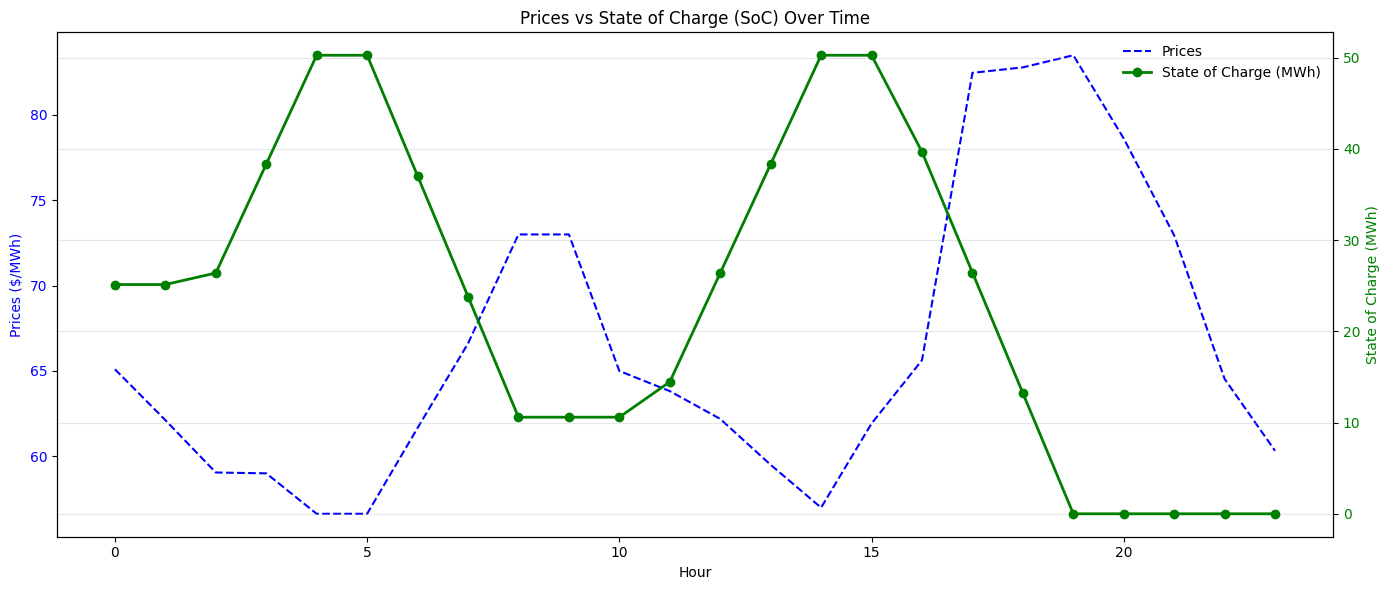

In [12]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Primary axis (Prices) ---
ax1.plot(hours, day_info[0].prices_buy, '--b', label='Prices')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Prices ($/MWh)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# --- Secondary axis (State of Charge) ---
ax2 = ax1.twinx()
ax2.plot(hours, np.array(result[0].soc[1:]) * batterydetails.capacity_MWh,
         '-og', label='State of Charge (MWh)', linewidth=2, markersize=6)
ax2.set_ylabel('State of Charge (MWh)', color='g')
ax2.tick_params(axis='y', labelcolor='g')


# --- Legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', frameon=False)

plt.title('Prices vs State of Charge (SoC) Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.labelsize": 18,     # x/y label size
    "axes.titlesize": 20,     # title size
    "xtick.labelsize": 14,    # tick size
    "ytick.labelsize": 14,
    "legend.fontsize": 16,    # legend text size
    "font.weight": "bold",    # make all text bold
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
})

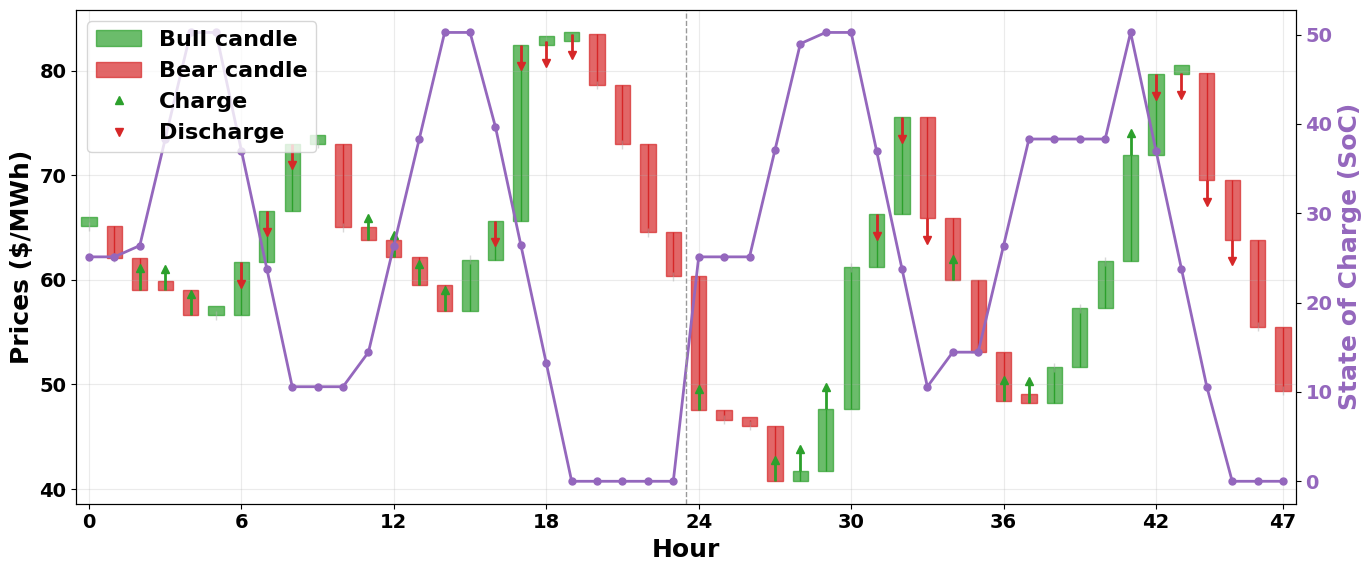

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_candles_with_soc(
    prices,                      # shape (24,) or (T,)
    soc,                         # SoC in [0,1] or MWh; shape (T,)
    *,
    capacity_MWh=None,           # if soc is [0,1] give capacity to convert on right axis
    actions=None,                # optional: array in [-1,1] (+charge, -discharge)
    soc_is_fraction=True,        # set False if soc already in MWh
    title="",
    candle_width=0.6,
    wick_width=0.1,
    tick_scale=0.8               # length of action stems in price units
):
    """
    Candles:
      open = price[t-1], close = price[t], high/low = max/min(open,close)
    Decision ticks:
      charge (a>0): green stem upward from price[t]
      discharge (a<0): red stem downward from price[t]
      neutral: no stem (or tiny gray nub)
    """

    prices = np.asarray(prices).astype(float)
    T = len(prices)
    hours = np.arange(T)

    # ----- derive open/close/high/low from the hourly series -----
    opens  = np.concatenate([[prices[0]], prices[:-1]])
    closes = prices
    highs  = np.maximum(opens, closes)
    lows   = np.minimum(opens, closes)

    # a small wick so candles are visible even if open==close
    eps = 1e-6
    highs = np.maximum(highs, lows + eps)

    # ----- actions (charge/discharge) -----
    if actions is None:
        # If no explicit actions, infer sign from SoC change:
        # positive delta SoC → charging; negative → discharging.
        soc_arr = np.asarray(soc, dtype=float)
        # align length to T
        if len(soc_arr) != T:
            # if user passed soc with 1 extra initial point, drop the first
            if len(soc_arr) == T + 1:
                soc_arr = soc_arr[1:]
            else:
                raise ValueError("soc length must be T or T+1 to infer actions.")
        dsoc = np.diff(soc_arr, prepend=soc_arr[0])
        actions = np.sign(dsoc)  # +1 charge, -1 discharge, 0 hold
    else:
        actions = np.asarray(actions, dtype=float)
        if len(actions) != T:
            raise ValueError("actions must have same length as prices.")

    # ----- plotting -----
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Candles
    for t in range(T):
        o, c, h, l = opens[t], closes[t], highs[t], lows[t]
        color = 'tab:green' if c >= o else 'tab:red'

        # wick
        ax1.vlines(t, l, h, linewidth=1, color=color)

        # body
        y = min(o, c)
        height = abs(c - o)
        # ensure visible body
        if height < (0.02 * np.ptp(prices) + 1e-9):
            height = 0.02 * np.ptp(prices) + 1e-9
        rect = Rectangle((t - candle_width/2, y), candle_width, height,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax1.add_patch(rect)

    # Decision ticks (stems from the CLOSE price)
    # Pick a tick length relative to the price range
    pr = np.ptp(prices) if np.ptp(prices) > 0 else 1.0
    L = tick_scale * 0.06 * pr

    for t in range(T):
        p = closes[t]
        a = actions[t]
        if a > 0:      # charge → green stem up
            ax1.vlines(t, p, p + L, linewidth=2, color='tab:green')
            ax1.plot([t], [p + L], marker='^', ms=6, color='tab:green')
        elif a < 0:    # discharge → red stem down
            ax1.vlines(t, p - L, p, linewidth=2, color='tab:red')
            ax1.plot([t], [p - L], marker='v', ms=6, color='tab:red')
        else:
            # optional small gray nub to indicate "hold"
            ax1.vlines(t, p - 0.01*pr, p + 0.01*pr, linewidth=1, color='0.7', alpha=0.5)

    # Axis styling for prices
    ax1.set_xlim(-0.5, T - 0.5)
    ax1.set_xticks(hours)
    ax1.set_xlabel("Hour")
    ax1.set_ylabel("Prices ($/MWh)")
    ax1.grid(alpha=0.25)

    # Secondary axis for SoC
    ax2 = ax1.twinx()
    soc_arr = np.asarray(soc, dtype=float)
    if len(soc_arr) == T + 1:   # many envs store soc[0..T]
        soc_arr = soc_arr[1:]
    if soc_is_fraction and capacity_MWh is not None:
        soc_plot = soc_arr * capacity_MWh
        ax2.set_ylabel("State of Charge (SoC)",  color='tab:purple')
    else:
        soc_plot = soc_arr
        ax2.set_ylabel("State of Charge (SoC)", color='tab:purple')

    ax2.plot(hours, soc_plot, '-o', linewidth=2, markersize=5, label="SoC", color='tab:purple')
    ax2.tick_params(axis='y', labelcolor='tab:purple')

    # Legends
    price_proxy_up = Rectangle((0,0),1,1, color='tab:green', alpha=0.7, label='Price ↑ (close≥open)')
    price_proxy_dn = Rectangle((0,0),1,1, color='tab:red',   alpha=0.7, label='Price ↓ (close<open)')
    stem_up_proxy  = plt.Line2D([0],[0], color='tab:green', marker='^', linestyle='None', label='Charge tick')
    stem_dn_proxy  = plt.Line2D([0],[0], color='tab:red',   marker='v', linestyle='None', label='Discharge tick')
    ax2.legend([price_proxy_up, price_proxy_dn, stem_up_proxy, stem_dn_proxy],
               ['Bull candle', 'Bear candle', 'Charge', 'Discharge'],
               loc='upper left', frameon=True)
    
    ax = plt.gca()
    ax.axvline(24 - 0.5, ls="--", lw=1, color="0.6")  # boundary between hour 23 and 24
    ax.set_xticks([0, 6, 12, 18, 24, 30, 36, 42, 47])
    ax.set_xticklabels(["0","6","12","18","24","30","36","42","47"])
    plt.draw()

    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- Example with your variables ----------
# prices = day_info[1].prices_buy                       # shape (24,)
# soc     = np.array(result[1].soc[1:])                 # length 24, SoC in [0,1]
# prices: hour-by-hour arrays (shape 24 each)
p1 = np.asarray(day_info[0].prices_buy, dtype=float)
p2 = np.asarray(day_info[1].prices_buy, dtype=float)
prices_48 = np.concatenate([p1, p2])                     # shape (48,)

# SoC: your result[i].soc likely has length 25 (t=0..24). We use [1:] to get 24 hourly points.
s1 = np.asarray(result[0].soc[1:], dtype=float)          # 24
s2 = np.asarray(result[1].soc[1:], dtype=float)          # 24
soc_48 = np.concatenate([s1, s2])                        # 48 (fraction 0..1)

# If you also have per-hour actions (in [-1,1]), you can concat them similarly:
# a1 = np.asarray(result[0].actions, dtype=float)
# a2 = np.asarray(result[1].actions, dtype=float)
# actions_48 = np.concatenate([a1, a2])

# ----- plot (the function from before) -----
plot_candles_with_soc(
    prices_48,
    soc_48,
    capacity_MWh=batterydetails.capacity_MWh,
    soc_is_fraction=True,
    # actions=actions_48,        # uncomment if you have explicit actions
)



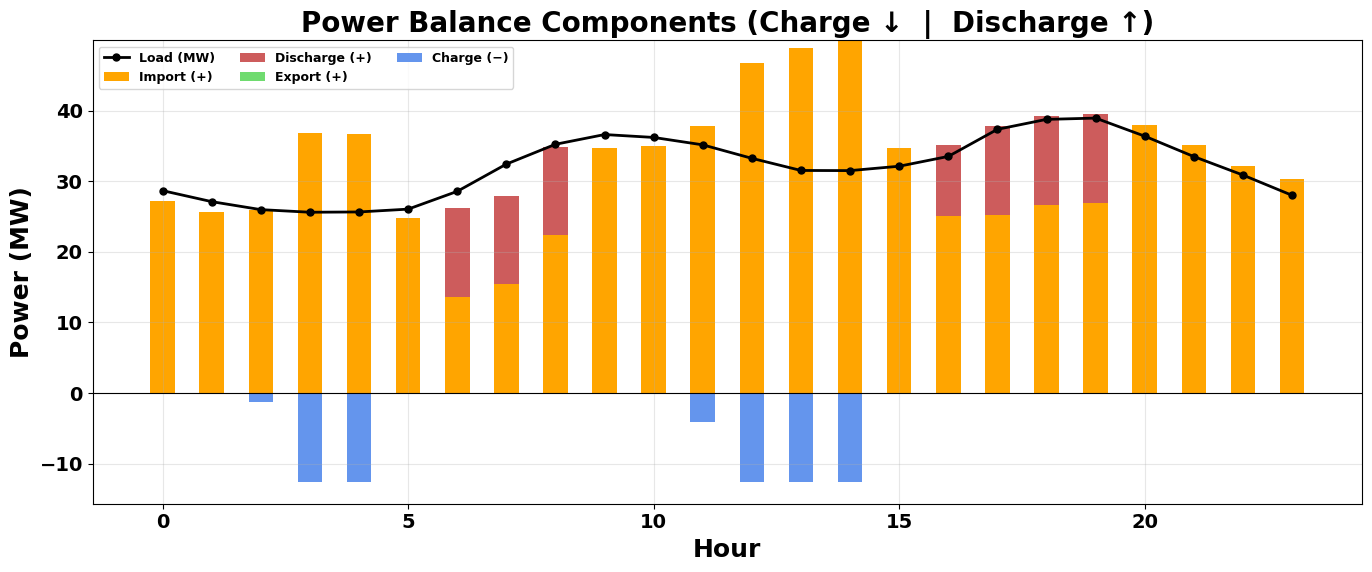

In [15]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)

# Data arrays
load = np.array(day_info[0].demand_MW)
charge = np.array(result[0].charge_MW)
discharge = np.array(result[0].discharge_MW)
import_MW = np.array(result[0].import_MW)
export_MW = np.array(result[0].export_MW) if getattr(day_info[0], "allow_export", False) else np.zeros_like(load)

# Flip battery convention for visualization
charge_vis = -charge       # show charge below 0
discharge_vis = discharge  # show discharge above 0

# ---------------------- PLOT ----------------------
fig, ax = plt.subplots(figsize=(14, 6))

# --- positive side stacking (Import + Discharge + Export) ---
# import is base layer
ax.bar(hours, import_MW, width=0.5, color='orange', label='Import (+)')
# discharge stacked on top of import
ax.bar(hours, discharge_vis, width=0.5, bottom=import_MW, color='indianred', label='Discharge (+)')
# export stacked on top (for clear separation)
ax.bar(hours, export_MW, width=0.5, bottom=import_MW + discharge_vis, color='limegreen', alpha=0.7, label='Export (+)')

# --- negative side stacking (Charge only) ---
ax.bar(hours, charge_vis, width=0.5, color='cornflowerblue', label='Charge (−)')

# --- Load as line ---
ax.plot(hours, load, '-ok', linewidth=2, markersize=5, label='Load (MW)')

# Formatting
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Power (MW)")
ax.set_xlabel("Hour")
ax.set_title("Power Balance Components (Charge ↓  |  Discharge ↑)")
ax.legend(ncol=3, loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
total_objective_value = 0
for day_result in result:
    total_objective_value += day_result.objective_cost
print(f"Total Objective Value over all days: ${total_objective_value:.2f} for {len(result)} days")

Total Objective Value over all days: $368352.05 for 8 days


In [17]:
result[0].objective_cost

46229.03813638294

In [18]:
# profit = day_info[0].prices_buy*discharge - day_info[0].prices_buy*charge
# print(profit.sum())

In [19]:
# len(decision_list)

In [20]:
# import pandas as pd
# italy_data = pd.read_csv("agentic_energy/data/ITALY_data.csv")
# italy_data.head()

In [21]:
# italy_data.shape

In [22]:
# 17496+24, 17496/24, len(soc_list)

In [23]:
# italy_data=italy_data.iloc[:len(decision_list)]
# soc_list = soc_list[:len(decision_list)]

In [24]:
# # I want to fill the decisions column in such a way that if soc_t > soc_t-1 then decision = 1 (charging)
# # if soc_t < soc_t-1 then decision = -1 (discharging)
# # if soc_t == soc_t-1 then decision = 0 (idle)
# italy_data["soc"] = soc_list
# italy_data['soc_prev'] = italy_data['soc'].shift(1)
# italy_data['decisions'] = 0  # Initialize with 0 (idle)
# italy_data.loc[italy_data['soc'] > italy_data['soc_prev'], 'decisions'] = 1   # Charging
# italy_data.loc[italy_data['soc'] < italy_data['soc_prev'], 'decisions'] = -1  # Discharging
# italy_data.loc[italy_data['soc'] == italy_data['soc_prev'], 'decisions'] = 0   # Idle



In [25]:
# italy_data.head()

In [26]:
# italy_data.to_csv("agentic_energy/data/ITALY_data_with_decisions.csv", index=False)

In [27]:
# help me create a dataframe to csv to store the results that we see in the plots
import pandas as pd



rows = []

for day_idx, day in enumerate(day_info):
    T = len(day.prices_buy)  # 24 in your case
    for t in range(T):
        rows.append({
            "prices_buy": day.prices_buy[t],
            "prices_buy_forecast": day.prices_buy_forecast[t],
            "demand_MW": day.demand_MW[t],
            "demand_MW_forecast": day.demand_MW_forecast[t],
            "soc": result[day_idx].soc[t],
            "charge_MW": result[day_idx].charge_MW[t],
            "discharge_MW": result[day_idx].discharge_MW[t],
            "import_MW": result[day_idx].import_MW[t],
            "export_MW": result[day_idx].export_MW[t],
            "profit_step": (result[day_idx].discharge_MW[t] - result[day_idx].charge_MW[t]) * day.prices_buy[t] * records.dt_hours
        })

df = pd.DataFrame(rows)

# help me calculate profit every 24 hours i.e. what is the profit for 1st day, 2d day, etc.
df["profit_daily"] = df.groupby(df.index // 24)["profit_step"].transform("sum")

df.to_csv(f"outputs/MILP_{data_version}_{forecast_type}.csv", index = False)

In [28]:
df.head()

,prices_buy,prices_buy_forecast,demand_MW,demand_MW_forecast,soc,charge_MW,discharge_MW,import_MW,export_MW,profit_step,profit_daily
0,65.10,55.675680,28.68,27.211635,0.500000,0.000000,0.0,27.211635,0.0,0.000000,2277.744223
1,62.12,53.072390,27.12,25.619468,0.500000,0.000000,0.0,25.619468,0.0,0.000000,2277.744223
2,59.05,51.001820,25.99,24.583980,0.500000,1.327368,0.0,25.911348,0.0,-78.381105,2277.744223
3,59.00,47.366238,25.62,24.221093,0.525095,12.560000,0.0,36.781093,0.0,-741.040000,2277.744223
4,56.63,47.407261,25.66,24.177718,0.762547,12.560000,0.0,36.737718,0.0,-711.272800,2277.744223


In [29]:
total_profit = df["profit_step"].sum()

print("Total arbitrage profit:", total_profit)

Total arbitrage profit: 16234.487293006932


In [30]:
data = (np.round(df["profit_daily"].unique(),2)[:-1])
data

array([2277.74, 2664.33, 2667.22, 2033.4 , 1446.77, 1870.49, 1281.64])

In [31]:
data.mean(), data.std()

(np.float64(2034.512857142857), np.float64(506.43168293221044))

In [32]:
df["prices_buy"].mean(), df["prices_buy"].std()

(np.float64(55.91432291666666), np.float64(10.48211828437552))

## Adding Ollama results here directly

In [45]:
ollama = pd.read_csv("battery_schedule_results_Ollama.csv")
ollama.head()

,soc,charge_MW,discharge_MW,import_MW,export_MW,net_MW,objective_cost,run_id
0,0.2375,0.00,12.3291,14.882535,0.0,14.882535,46344.477187,0
1,0.2375,0.00,0.0000,25.619468,0.0,25.619468,46344.477187,0
2,0.4750,12.36,0.0000,36.943980,0.0,36.943980,46344.477187,0
3,0.7125,12.36,0.0000,36.581093,0.0,36.581093,46344.477187,0
4,0.9500,12.36,0.0000,36.537718,0.0,36.537718,46344.477187,0


In [46]:
df.shape, ollama.shape

((192, 11), (168, 8))

In [47]:
df.iloc[:-24].columns

Index(['prices_buy', 'prices_buy_forecast', 'demand_MW', 'demand_MW_forecast',
       'soc', 'charge_MW', 'discharge_MW', 'import_MW', 'export_MW',
       'profit_step', 'profit_daily'],
      dtype='object')

In [48]:
ollama["prices_buy"] = df.iloc[:-24]["prices_buy"]
ollama["prices_buy_forecast"] = df.iloc[:-24]["prices_buy_forecast"]
ollama["demand_MW"] = df.iloc[:-24]["demand_MW"]
ollama["demand_MW_forecast"] = df.iloc[:-24]["demand_MW_forecast"]
ollama["profit_step"] = (ollama["discharge_MW"] - ollama["charge_MW"]) * ollama["prices_buy"] * day.dt_hours

ollama["profit_daily"] = ollama.groupby(ollama.index // 24)["profit_step"].transform("sum")
ollama.to_csv(f"outputs/MILP_{data_version}_{forecast_type}.csv", index = False)


In [49]:
ollama.head()

,soc,charge_MW,discharge_MW,import_MW,export_MW,net_MW,objective_cost,run_id,prices_buy,prices_buy_forecast,demand_MW,demand_MW_forecast,profit_step,profit_daily
0,0.2375,0.00,12.3291,14.882535,0.0,14.882535,46344.477187,0,65.10,55.675680,28.68,27.211635,802.62441,2512.010561
1,0.2375,0.00,0.0000,25.619468,0.0,25.619468,46344.477187,0,62.12,53.072390,27.12,25.619468,0.00000,2512.010561
2,0.4750,12.36,0.0000,36.943980,0.0,36.943980,46344.477187,0,59.05,51.001820,25.99,24.583980,-729.85800,2512.010561
3,0.7125,12.36,0.0000,36.581093,0.0,36.581093,46344.477187,0,59.00,47.366238,25.62,24.221093,-729.24000,2512.010561
4,0.9500,12.36,0.0000,36.537718,0.0,36.537718,46344.477187,0,56.63,47.407261,25.66,24.177718,-699.94680,2512.010561


In [50]:
total_profit = ollama["profit_step"].sum()

print("Total arbitrage profit:", total_profit)

Total arbitrage profit: 12711.785121843264


In [51]:
data = (np.round(ollama["profit_daily"].unique(),2))
data

array([2512.01, 1916.68, 2612.67, 1867.29, 1322.08, 1679.82,  801.24])

In [52]:
data.mean(), data.std()

(np.float64(1815.97), np.float64(588.4750201762422))